In [4]:
# importing libraries
import numpy as np 
import pandas as pd
import uproot 
from glob import glob 

In [5]:
branches = ['fEvent', 'fX', 'fY', 'fZ', 'fEdep',
            'fdEdx', 'Ekin', 'TOF', 'TrackLength',
            'ScatteringAng', 'Momentum']

# cargamos los hits 
def load_hits(pattern):
    files = sorted(glob(pattern))
    dfs = []
    for run_id, path in enumerate(files):
        with uproot.open(path) as f:
            # Pick the cycle with the most entries (handles ROOT multi-cycle files)
            best_key = max(f.keys(), key=lambda k: f[k].num_entries)
            tree = f[best_key]
            data = {b: tree[b].array(library='np').astype(np.float64) for b in branches}
            df = pd.DataFrame(data)
            df['run_id'] = run_id
            df['event_uid'] = df['run_id'].astype(str) + '_' + df['fEvent'].astype(str)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)
    

hits_mu = load_hits('data/muon/output_run*.root')
hits_pi = load_hits('data/pion/output_run*.root')

print(hits_mu.shape)
print(hits_pi.shape)


(30397026, 13)
(39844472, 13)


In [6]:
def aggregate_events(hits_df, label):
    g = hits_df.groupby('event_uid')

    feats = pd.DataFrame(
        {
            "n_hits": g['fEvent'].count(),
            'n_unique_cells': g[['fX', 'fY', 'fZ']].apply(lambda x: len(x.drop_duplicates())),

            # Deposito de energia
            'edep_sum': g['fEdep'].sum(),
            'edep_max': g['fEdep'].max(),
            'edep_std': g['fEdep'].std().fillna(0),

            # dE/dx
            'dedx_mean': g['fdEdx'].mean(),
            'dedx_max': g['fdEdx'].max(),
            'dedx_std': g['fdEdx'].std().fillna(0),

            # energia cinetica 
            'ekin_first': g['Ekin'].first(),
            'ekin_last': g['Ekin'].last(),
            'ekin_loss': g['Ekin'].first() - g['Ekin'].last(),

            # TOF: tiempo de vuelo
            'tof_first': g['TOF'].first(),
            'tof_last': g['TOF'].last(),
            'tof_range': g['TOF'].max() - g['TOF'].min(),

            # Longitud de trayectoria
            'track_first': g['TrackLength'].first(),
            'track_last': g['TrackLength'].last(),
            'track_mean': g['TrackLength'].mean(),

            # Scattering angle 
            'scat_mean': g['ScatteringAng'].mean(),
            'scat_max': g['ScatteringAng'].max(),
            'scat_std': g['ScatteringAng'].std().fillna(0),

            # geometria transversal
            'radial_spread': g.apply(lambda x: np.sqrt(x['fX'].var() + x['fY'].var()), 
                                        include_groups=False).fillna(0),
            'z_span': g['fZ'].max() - g['fZ'].min(),
    })

    feats['label'] = label
    return feats.reset_index()

events_mu = aggregate_events(hits_mu, label=1)
events_pi = aggregate_events(hits_pi, label=0)

df = pd.concat([events_mu, events_pi], ignore_index=True)
print(df.shape)
print(df['label'].value_counts())





(20000, 24)
label
1    10000
0    10000
Name: count, dtype: int64


In [7]:
df.head()

,event_uid,n_hits,n_unique_cells,edep_sum,edep_max,edep_std,dedx_mean,dedx_max,dedx_std,ekin_first,...,tof_range,track_first,track_last,track_mean,scat_mean,scat_max,scat_std,radial_spread,z_span,label
0,0_0.0,375,3,999.991731,106.637407,9.231303,2.640943,163.505976,10.088434,999.991731,...,2.812270,91.183959,1.664138,97.262077,0.381778,3.081673,0.736481,34.608068,0.0,1
1,0_1.0,357,5,999.992875,92.088296,9.743358,2.336334,151.601906,9.001007,999.992875,...,2.837739,82.652402,1.274096,97.663387,0.303393,2.917190,0.608329,43.168645,0.0,1
2,0_10.0,397,3,999.991538,67.945226,8.032095,2.913236,148.284879,9.845559,999.991538,...,2.841539,84.782356,1.128634,100.148510,0.343993,2.938068,0.680350,21.049844,0.0,1
3,0_100.0,371,2,999.993090,100.993883,9.651751,3.075705,183.513714,11.696207,999.993090,...,2.874791,82.048940,1.081025,101.909346,0.341832,2.779990,0.661746,21.514724,0.0,1
4,0_101.0,327,3,999.991586,99.940040,8.915514,2.258952,191.143998,11.315361,999.991586,...,2.788072,89.455521,0.005371,120.627083,0.376357,2.892677,0.675020,55.656900,0.0,1


In [8]:
# Splitting the data into training and testing sets

from sklearn.model_selection import train_test_split 

FEATURES = [c for c in df.columns if c not in ('event_uid', 'label')]

X = df[FEATURES]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
stratify=y, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(16000, 22) (4000, 22) (16000,) (4000,)


In [9]:

from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    early_stopping_rounds=20,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)


scale_pos_weight: 1.00


In [10]:

model.fit(X_train, y_train,
eval_set=[(X_test, y_test)],
verbose=50)

[0]	validation_0-logloss:0.64454
[50]	validation_0-logloss:0.04087
[100]	validation_0-logloss:0.00447
[150]	validation_0-logloss:0.00136
[200]	validation_0-logloss:0.00097
[250]	validation_0-logloss:0.00089
[259]	validation_0-logloss:0.00089


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'logloss'


ROC-AUC Score: 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



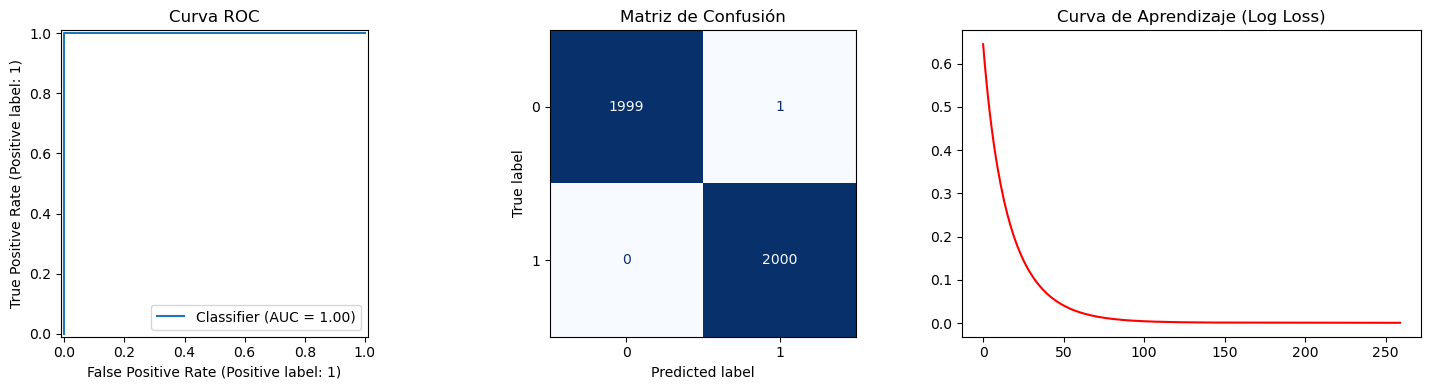

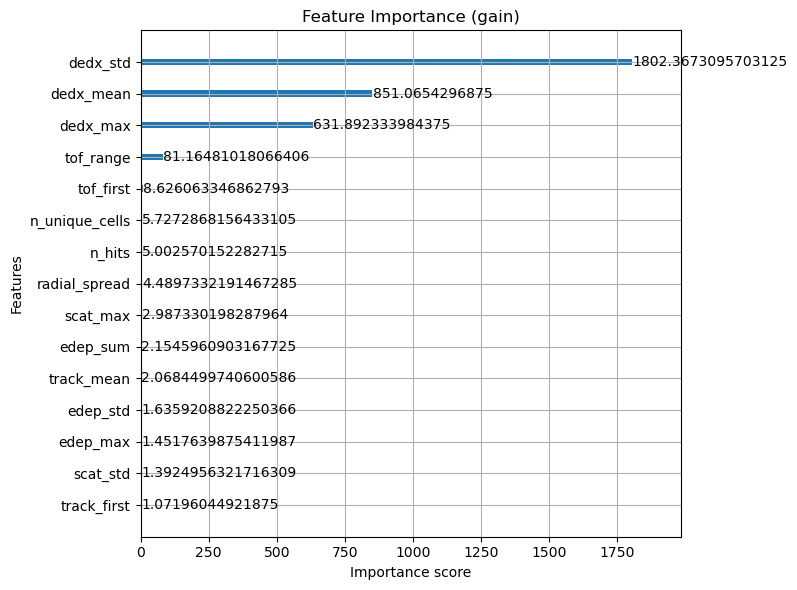

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
import xgboost as xgb

# 1. Predicciones y Reporte de texto
y_pred, y_prob = model.predict(X_test), model.predict_proba(X_test)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}\n")
print(classification_report(y_test, y_pred))

# 2. Gráficas (ROC, Matriz de Confusión y Curva de Aprendizaje)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[0])
ax[0].set_title("Curva ROC")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', colorbar=False, ax=ax[1])
ax[1].set_title("Matriz de Confusión")

ax[2].plot(model.evals_result()['validation_0']['logloss'], color='red')
ax[2].set_title("Curva de Aprendizaje (Log Loss)")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
xgb.plot_importance(model, importance_type='gain', ax=ax, max_num_features=15)
ax.set_title("Feature Importance (gain)")
plt.tight_layout()
plt.show()

In [12]:
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn.metrics import roc_auc_score 

df_test = X_test.copy()
df_test['y_true'] = y_test.values 
df_test['y_pred'] = y_pred 
df_test['y_prob'] = y_prob 

bins = [900, 1500, 2500, 4500, 7500, 11000]
labels = ['1.0-1.5 GeV', '1.5-2.5 GeV', '2.5-4.5 GeV', '4.5-7.5 GeV', '7.5-11 GeV']
df_test['ekin_bin'] = pd.cut(df_test['ekin_first'], bins, labels=labels)

resultados = []

for bin_label in labels:
    subset = df_test[df_test['ekin_bin'] == bin_label]
    n = len(subset)
    if n==0:
        continue
    error_rate = (subset['y_true'] != subset['y_pred']).mean()*100
    clases = subset['y_true'].nunique()
    auc = roc_auc_score(subset['y_true'], subset['y_prob']) if clases ==2 else None

    resultados.append({
        'Rango': bin_label,
        'N_eventos': n,
        'Error': round(error_rate, 2),
        'ROC-AUC': round(auc,4) if auc else 'N/A (1 clase)'
    })


      Rango  N_eventos  Error  ROC-AUC
1.0-1.5 GeV        825   0.00      1.0
1.5-2.5 GeV        753   0.00      1.0
2.5-4.5 GeV        789   0.00      1.0
4.5-7.5 GeV        824   0.12      1.0
 7.5-11 GeV        808   0.00      1.0


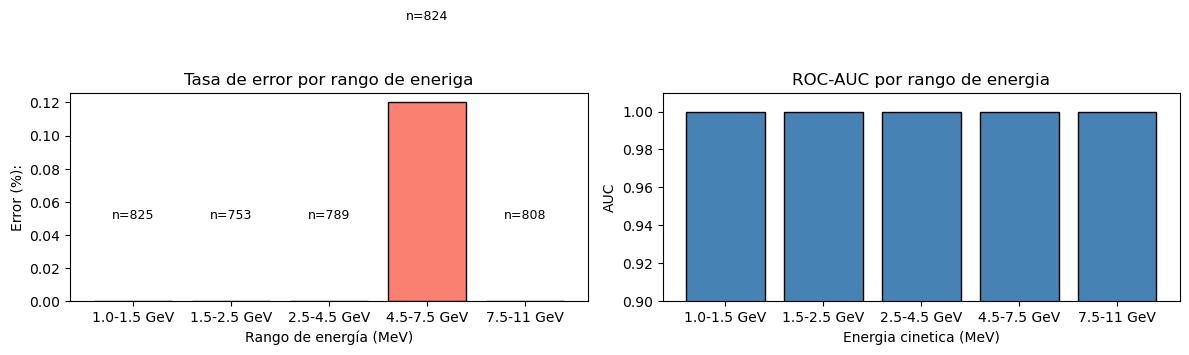

In [13]:
import pandas as pd
df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False))

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].bar(df_res['Rango'], df_res['Error'], color='salmon', 
edgecolor='black')

axes[0].set_title('Tasa de error por rango de eneriga')
axes[0].set_ylabel("Error (%):")
axes[0].set_xlabel("Rango de energía (MeV)")

for i, row in df_res.iterrows():
      axes[0].text(i, row['Error'] + 0.05, f"n={row['N_eventos']}",
                   ha='center', fontsize=9)

aucs = [r['ROC-AUC'] if isinstance(r['ROC-AUC'], float) else 0 for _, r in  
df_res.iterrows()]

axes[1].bar(df_res['Rango'], aucs, color='steelblue', edgecolor='black')
axes[1].set_title('ROC-AUC por rango de energia')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0.9, 1.01)
axes[1].set_xlabel('Energia cinetica (MeV)')

plt.tight_layout()
plt.show()

